In [18]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

print(sys.path[-1])

c:\Users\Sag\Desktop\AI_Course_Recommendation_System


In [1]:
import pandas as pd
import numpy as np

students = pd.read_csv("../data/processed/students.csv")
courses = pd.read_csv("../data/processed/courses.csv")
interactions = pd.read_csv("../data/processed/student_interactions.csv")

print(students.shape)
print(courses.shape)
print(interactions.shape)

(100, 4)
(50, 4)
(1000, 5)


In [2]:
relevant_interactions = interactions[
    (interactions["quiz_score"] >= 70) &
    (interactions["completion_rate"] >= 70)
]

print("Relevant interactions:", len(relevant_interactions))

Relevant interactions: 212


In [3]:
ground_truth = (
    relevant_interactions
    .groupby("student_id")["course_id"]
    .apply(set)
    .to_dict()
)

print(
    "Students with relevant courses:",
    len(ground_truth)
)

Students with relevant courses: 90


In [4]:
popular_courses = (
    interactions
    .groupby("course_id")
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

popular_courses

[7, 26, 42, 45, 50]

In [5]:
def precision_at_k(
    recommended,
    relevant,
    k=5
):

    recommended = recommended[:k]

    hits = len(
        set(recommended)
        &
        set(relevant)
    )

    return hits / k

In [6]:
precision_scores = []

for student_id, relevant in ground_truth.items():

    score = precision_at_k(
        popular_courses,
        relevant,
        5
    )

    precision_scores.append(score)

print(
    "Popularity Precision@5:",
    np.mean(precision_scores)
)

Popularity Precision@5: 0.06666666666666667


In [7]:
course_features = courses.copy()

course_features["combined_features"] = (
    course_features["subject"]
    + " "
    + course_features["difficulty"]
)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

course_matrix = tfidf.fit_transform(
    course_features["combined_features"]
)

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    course_matrix
)

In [10]:
def content_based_recommend(
    course_id,
    top_n=5
):

    idx = course_features[
        course_features["course_id"] == course_id
    ].index[0]

    similarity_scores = list(
        enumerate(
            similarity_matrix[idx]
        )
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for i in similarity_scores[1:top_n+1]:
        recommendations.append(
            course_features.iloc[i[0]]["course_id"]
        )

    return recommendations

In [11]:
content_precision_scores = []

for student_id, relevant_courses in ground_truth.items():

    relevant_courses = list(relevant_courses)

    if len(relevant_courses) == 0:
        continue

    seed_course = relevant_courses[0]

    recommended = content_based_recommend(
        seed_course,
        5
    )

    score = precision_at_k(
        recommended,
        relevant_courses,
        5
    )

    content_precision_scores.append(score)

print(
    "Content-Based Precision@5:",
    np.mean(content_precision_scores)
)

Content-Based Precision@5: 0.17555555555555555


In [12]:
user_course_matrix = interactions.pivot_table(
    index="student_id",
    columns="course_id",
    values="quiz_score",
    fill_value=0
)

user_course_matrix.head()

course_id,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
student_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,75.0,0.0,0.0,89.0,0.0,67.0,...,36.0,0.0,0.0,0.0,84.0,68.0,0.0,50.0,0.0,0.0
2,32.0,0.0,0.0,98.0,0.0,0.0,0.0,85.0,0.0,0.0,...,74.0,98.0,0.0,0.0,0.0,0.0,0.0,0.0,47.5,0.0
3,0.0,0.0,0.0,0.0,51.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,95.0,0.0,0.0,0.0,0.0,48.0
4,76.0,0.0,0.0,0.0,74.0,38.0,83.0,92.0,0.0,0.0,...,0.0,0.0,0.0,75.0,0.0,0.0,0.0,0.0,0.0,53.0
5,0.0,0.0,0.0,0.0,86.0,0.0,0.0,0.0,0.0,0.0,...,0.0,62.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(
    user_course_matrix
)

user_similarity.shape

(100, 100)

In [14]:
user_ids = user_course_matrix.index.tolist()

def collaborative_recommend(
    student_id,
    top_n=5
):

    user_idx = user_ids.index(student_id)

    similarity_scores = list(
        enumerate(
            user_similarity[user_idx]
        )
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similar_users = similarity_scores[1:6]

    recommended_courses = {}

    for similar_user_idx, score in similar_users:

        similar_user_id = user_ids[
            similar_user_idx
        ]

        user_courses = interactions[
            interactions["student_id"]
            == similar_user_id
        ]["course_id"]

        for course in user_courses:

            recommended_courses[
                course
            ] = recommended_courses.get(
                course,
                0
            ) + score

    ranked = sorted(
        recommended_courses.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [
        course_id
        for course_id, _
        in ranked[:top_n]
    ]

In [15]:
cf_precision_scores = []

for student_id, relevant_courses in ground_truth.items():

    recommended = collaborative_recommend(
        student_id,
        5
    )

    score = precision_at_k(
        recommended,
        relevant_courses,
        5
    )

    cf_precision_scores.append(score)

print(
    "Collaborative Precision@5:",
    np.mean(cf_precision_scores)
)

Collaborative Precision@5: 0.27111111111111114


In [28]:
import joblib

model = joblib.load("../models/student_success_model.pkl")

print("Model loaded")

Model loaded


In [29]:
import pandas as pd

def predict_success(quiz_score, completion_rate):

    sample = pd.DataFrame([{
        "quiz_score": quiz_score,
        "completion_rate": completion_rate
    }])

    return model.predict_proba(sample)[0][1]

print(predict_success(80, 90))

1.0


In [30]:
data = interactions.merge(
    students,
    on="student_id"
)

data = data.merge(
    courses,
    on="course_id"
)

data["performance_score"] = (
    data["quiz_score"] * 0.6 +
    data["completion_rate"] * 0.4
)

print(data.shape)

(1000, 12)


In [31]:
def hybrid_recommend(student_id, top_n=5):

    student_data = data[
        data["student_id"] == student_id
    ].copy()

    recommendations = []

    for _, row in student_data.iterrows():

        success_prob = predict_success(
            row["quiz_score"],
            row["completion_rate"]
        )

        recommendation_score = 0

        if row["subject"] == row["preferred_subject"]:
            recommendation_score += 30

        if row["performance_score"] < 60:
            recommendation_score += 40

        if (
            row["skill_level"] == "Beginner"
            and row["difficulty"] == "Beginner"
        ):
            recommendation_score += 20

        recommendation_score += (
            row["completion_rate"] * 0.1
        )

        final_score = (
            recommendation_score * 0.4
            +
            success_prob * 100 * 0.6
        )

        recommendations.append(
            (row["course_id"], final_score)
        )

    recommendations = sorted(
        recommendations,
        key=lambda x: x[1],
        reverse=True
    )

    return [
        course_id
        for course_id, _
        in recommendations[:top_n]
    ]

In [32]:
hybrid_precision_scores = []

for student_id, relevant_courses in ground_truth.items():

    recommended = hybrid_recommend(
        student_id,
        5
    )

    score = precision_at_k(
        recommended,
        relevant_courses,
        5
    )

    hybrid_precision_scores.append(score)

print(
    "Hybrid Precision@5:",
    np.mean(hybrid_precision_scores)
)

Hybrid Precision@5: 0.46222222222222226


In [33]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Popularity-Based",
        "Content-Based",
        "Collaborative Filtering",
        "Hybrid + Random Forest"
    ],
    "Precision@5": [
        0.0667,
        0.1756,
        0.2711,
        0.4622
    ]
})

results

,Model,Precision@5
0,Popularity-Based,0.0667
1,Content-Based,0.1756
2,Collaborative Filtering,0.2711
3,Hybrid + Random Forest,0.4622


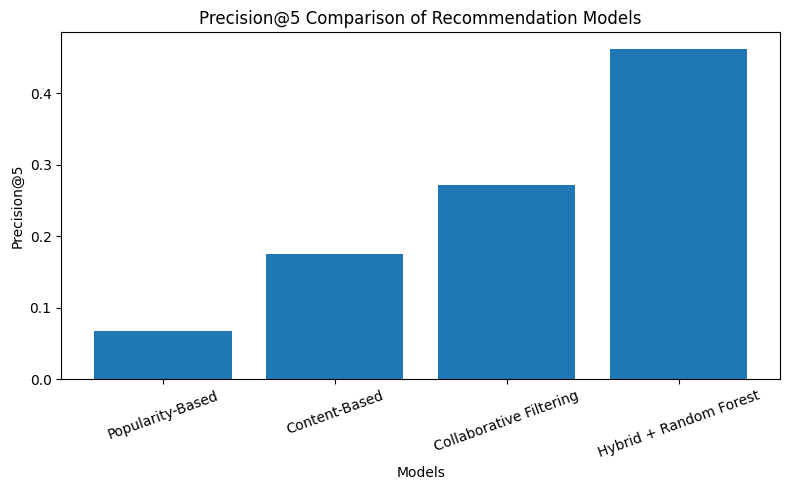

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Precision@5"]
)

plt.title(
    "Precision@5 Comparison of Recommendation Models"
)

plt.xlabel("Models")
plt.ylabel("Precision@5")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../results/precision_comparison.png",
    dpi=300
)

plt.show()

In [35]:
results.to_csv(
    "../results/evaluation_results.csv",
    index=False
)

print("Results saved")

Results saved


Experimental Results

The proposed Performance-Aware Hybrid Course Recommendation System achieved the highest Precision@5 score of 0.4622.

Compared with traditional recommendation approaches:

- Popularity-Based: 0.0667
- Content-Based: 0.1756
- Collaborative Filtering: 0.2711
- Hybrid + Random Forest: 0.4622

The proposed model improved recommendation precision by approximately 70.5% compared to Collaborative Filtering and nearly 7 times compared to the Popularity-Based baseline.

These results demonstrate that incorporating student performance prediction into the recommendation process significantly improves recommendation relevance and personalization.